### Setup and Configuration

In [18]:
# CELL 1: Setup, Configuration, and Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math, random, re
import json
from pathlib import Path

# --- CONFIGURATION ---
# Automatically find the latest pipeline run via the pointer file
OUTPUT_ROOT = Path("./data/derived")
latest_run_ptr = OUTPUT_ROOT / "psycomark_latest.txt"

if not latest_run_ptr.exists():
    raise FileNotFoundError(f"Could not find pointer file at '{latest_run_ptr}'. Please run data_pipeline.py first.")

PIPELINE_OUTPUT_DIR = Path(latest_run_ptr.read_text().strip())
print(f"--- Loading data from latest pipeline run: {PIPELINE_OUTPUT_DIR.name} ---")

# --- Load Data and Manifest ---
train_df = pd.read_json(PIPELINE_OUTPUT_DIR / "train.jsonl", lines=True)
dev_df = pd.read_json(PIPELINE_OUTPUT_DIR / "dev.jsonl", lines=True)

with open(PIPELINE_OUTPUT_DIR / "manifest.json") as f:
    manifest = json.load(f)

# --- Report Key Stats from Manifest ---
print("\n=== Pipeline Run Summary ===")
sizes = manifest.get('sizes', {})
print(f"Train Set: {sizes.get('train_raw', 'N/A')} raw -> {sizes.get('train_final', 'N/A')} final")
print(f"  - Docs removed due to dev set leakage: {sizes.get('train_docs_removed_leakage', 'N/A')}")
print(f"  - Docs removed as internal duplicates: {sizes.get('train_docs_removed_internal_dups', 'N/A')}")
print(f"Dev Set:   {sizes.get('dev_raw', 'N/A')} raw -> {sizes.get('dev_final', 'N/A')} final (dev set is preserved)")
print("============================")


# --- Prepare Combined DataFrame for Analysis ---
train_df['split'] = 'train'
dev_df['split'] = 'dev'
df_all = pd.concat([train_df, dev_df], ignore_index=True)

# Recreate the spans dataframe for span-level analyses
span_rows = []
for _, row in df_all.iterrows():
    for m in (row["markers"] or []):
        if isinstance(m.get("start"), int) and isinstance(m.get("end"), int):
             span_rows.append({
                "doc_id": row["doc_id"], "label": m["label"],
                "start": m["start"], "end": m["end"],
                "char_len": m["end"] - m["start"]
             })
df_spans = pd.DataFrame(span_rows)

print("\nData loaded and prepared for analysis.")

--- Loading data from latest pipeline run: psycomark_official_split_20251005_140323 ---

=== Pipeline Run Summary ===
Train Set: 3682 raw -> 3360 final
  - Docs removed due to dev set leakage: 20
  - Docs removed as internal duplicates: N/A
Dev Set:   100 raw -> 100 final (dev set is preserved)

Data loaded and prepared for analysis.


#### Inputs

In [19]:
ALLOWED = {"Actor","Action","Effect","Victim","Evidence"}
SEED = 42
rng = np.random.default_rng(SEED)

# Flat spans (train only is fine for descriptive stats)
rows = []
for split_name, df in [("train", train_df)]:  # add dev if you want
    for _, r in df.iterrows():
        text = r.get("text") or ""
        for m in r.get("markers") or []:
            lab = m.get("label")
            if lab in ALLOWED:
                rows.append({
                    "doc_id": r["doc_id"],
                    "label": lab,
                    "start": int(m["start"]),
                    "end":   int(m["end"]),
                    "text_len": len(text)
                })
spans = pd.DataFrame(rows)
texts = {r["doc_id"]: (r["text"] or "") for _, r in train_df.iterrows()}
len(spans), len(texts)

(17328, 3360)

### Pairwise IoU stats + 95% bootstrap CIs (stratified by doc)

In [20]:
# --- Cell B: pairwise IoU + bootstrap CIs ---
def iou(a, b):
    s1,e1 = a; s2,e2 = b
    inter = max(0, min(e1,e2) - max(s1,s2))
    if inter <= 0: return 0.0
    union = (e1 - s1) + (e2 - s2) - inter
    return inter / union if union > 0 else 0.0

# gather overlaps per (label-pair, doc) to enable doc-level bootstrap
from collections import defaultdict

per_pair_per_doc = defaultdict(list)  # key=(labA,labB), val=list of dicts per doc: {'doc_id', 'ious':[...]}

for doc_id, g in spans.groupby("doc_id"):
    recs = g[["label","start","end"]].to_records(index=False)
    recs = [(str(L), int(S), int(E)) for (L,S,E) in recs]
    # compute all cross-label IOUs within this doc
    pair_to_ious = defaultdict(list)
    for i in range(len(recs)):
        lab1,s1,e1 = recs[i]
        for j in range(i+1, len(recs)):
            lab2,s2,e2 = recs[j]
            if lab1 == lab2: 
                continue
            pair = tuple(sorted([lab1,lab2]))
            val = iou((s1,e1),(s2,e2))
            if val > 0:
                pair_to_ious[pair].append(val)
    for pair, ious in pair_to_ious.items():
        per_pair_per_doc[pair].append({"doc_id": doc_id, "ious": ious})

def bootstrap_ci_doc_level(vals, B=1000, alpha=0.05, rng=rng):
    """vals: list of scalars; resample at doc-level with replacement."""
    if len(vals) == 0:
        return (None, None)
    stats = []
    V = np.asarray(vals, float)
    n = len(V)
    for _ in range(B):
        s = rng.choice(V, size=n, replace=True)
        stats.append(float(np.mean(s)))
    lo, hi = np.quantile(stats, [alpha/2, 1-alpha/2])
    return float(lo), float(hi)

pair_stats_ci = {}
for pair, rows in per_pair_per_doc.items():
    # flatten per-doc metrics
    doc_means = [np.mean(r["ious"]) for r in rows]                 # mean IoU per doc
    doc_rate01 = [np.mean([x>=0.1 for x in r["ious"]]) for r in rows]  # IoU@0.1 per doc
    doc_rate05 = [np.mean([x>=0.5 for x in r["ious"]]) for r in rows]  # IoU@0.5 per doc

    pair_stats_ci["/".join(pair)] = {
        "n_docs": len(rows),
        "mean_iou": float(np.mean(doc_means)),
        "mean_iou_ci": list(bootstrap_ci_doc_level(doc_means)),
        "iou@0.1": float(np.mean(doc_rate01)),
        "iou@0.1_ci": list(bootstrap_ci_doc_level(doc_rate01)),
        "iou@0.5": float(np.mean(doc_rate05)),
        "iou@0.5_ci": list(bootstrap_ci_doc_level(doc_rate05)),
    }

with open(PIPELINE_OUTPUT_DIR / "overlap_pair_stats_ci.json", "w", encoding="utf-8") as f:
    json.dump(pair_stats_ci, f, indent=2)
(pair_stats_ci.get("Action/Effect"), pair_stats_ci.get("Actor/Victim"))[:]


({'n_docs': 184,
  'mean_iou': 0.5669566170349147,
  'mean_iou_ci': [0.519447219785102, 0.613184692944956],
  'iou@0.1': 0.9402173913043478,
  'iou@0.1_ci': [0.907608695652174, 0.970108695652174],
  'iou@0.5': 0.47554347826086957,
  'iou@0.5_ci': [0.39938858695652174, 0.5489130434782609]},
 {'n_docs': 63,
  'mean_iou': 0.596113171753979,
  'mean_iou_ci': [0.5044495132985104, 0.6844218234307322],
  'iou@0.1': 0.8888888888888888,
  'iou@0.1_ci': [0.8095238095238095, 0.9523809523809523],
  'iou@0.5': 0.5502645502645502,
  'iou@0.5_ci': [0.42857142857142855, 0.6667989417989416]})

### Boundary context extraction (chars + 1–2-word tokens)

In [21]:
# --- Cell C: boundary context (chars + tokens) ---
from collections import Counter

def word_tokens(s):
    return re.findall(r"[A-Za-z0-9_]+", s)

K_CHARS = 5    # context width in characters
TOP = 25       # top items to keep

ctx = {lab: {"before_chars": Counter(), "after_chars": Counter(),
             "before_1w": Counter(), "after_1w": Counter(),
             "before_2w": Counter(), "after_2w": Counter()}
       for lab in ALLOWED}

for _, row in spans.iterrows():
    t = texts.get(row["doc_id"], "")
    s, e, L = int(row["start"]), int(row["end"]), row["label"]
    # char windows
    before_c = t[max(0, s-K_CHARS):s]
    after_c  = t[e:min(len(t), e+K_CHARS)]
    if before_c: ctx[L]["before_chars"][before_c] += 1
    if after_c:  ctx[L]["after_chars"][after_c]  += 1
    # token windows
    before_w = word_tokens(t[:s])[-2:]  # last two tokens before start
    after_w  = word_tokens(t[e:])[:2]   # first two tokens after end
    if before_w:
        ctx[L]["before_1w"][" ".join(before_w[-1:])] += 1
        if len(before_w)>=2: ctx[L]["before_2w"][" ".join(before_w[-2:])] += 1
    if after_w:
        ctx[L]["after_1w"][" ".join(after_w[:1])] += 1
        if len(after_w)>=2: ctx[L]["after_2w"][" ".join(after_w[:2])] += 1

boundary_context = {}
for lab, d in ctx.items():
    boundary_context[lab] = {
        "before_chars": [w for w,_ in d["before_chars"].most_common(TOP)],
        "after_chars":  [w for w,_ in d["after_chars"].most_common(TOP)],
        "before_1w":    [w for w,_ in d["before_1w"].most_common(TOP)],
        "after_1w":     [w for w,_ in d["after_1w"].most_common(TOP)],
        "before_2w":    [w for w,_ in d["before_2w"].most_common(TOP)],
        "after_2w":     [w for w,_ in d["after_2w"].most_common(TOP)],
    }

with open(PIPELINE_OUTPUT_DIR / "boundary_context.json", "w", encoding="utf-8") as f:
    json.dump(boundary_context, f, indent=2)
boundary_context["Action"].keys()


dict_keys(['before_chars', 'after_chars', 'before_1w', 'after_1w', 'before_2w', 'after_2w'])

#### Helper functions

In [7]:
def iou(a: tuple, b: tuple) -> float:
    """Compute Intersection over Union (IoU) of two spans a and b.
    a and b are tuples (start, end)
    Returns IoU value between 0 and 1.
    """
    s1,e1 = a; s2,e2 = b
    inter = max(0, min(e1,e2) - max(s1,s2))
    if inter == 0: return 0.0
    union = (e1 - s1) + (e2 - s2) - inter
    return inter / union

def overlap_stats_for_pairs(df: pd.DataFrame) -> dict:
    """Compute overlap statistics for each pair of labels in the spans dataframe.
    Returns a dict of stats per label pair.
    """
    # df must have columns: doc_id, label, start, end
    from collections import defaultdict
    per_pair = defaultdict(list)
    for doc_id, g in df.groupby("doc_id"):
        spans = g[["label","start","end"]].to_records(index=False)
        spans = [(lab,int(s),int(e)) for (lab,s,e) in spans]
        for i in range(len(spans)):
            lab1,s1,e1 = spans[i]
            for j in range(i+1, len(spans)):
                lab2,s2,e2 = spans[j]
                if lab1 == lab2: continue
                iou_val = iou((s1,e1),(s2,e2))
                if iou_val == 0: continue
                pair = tuple(sorted([lab1, lab2]))
                starts_first = 1 if s1 < s2 else 0
                contains = int(s1 <= s2 and e1 >= e2) or int(s2 <= s1 and e2 >= e1)
                per_pair[pair].append({"iou": iou_val, "a_starts_first": starts_first, "contain": contains})
    # aggregate
    out = {}
    for pair, rows in per_pair.items():
        xs = [r["iou"] for r in rows]
        out["/".join(pair)] = {
            "n": len(xs),
            "mean_iou": float(np.mean(xs)),
            "median_iou": float(np.median(xs)),
            "iou@0.1": float(np.mean([x>=0.1 for x in xs])),
            "iou@0.5": float(np.mean([x>=0.5 for x in xs])),
            "starts_first_rate": float(np.mean([r["a_starts_first"] for r in rows])),
            "contain_rate": float(np.mean([r["contain"] for r in rows])),
        }
    return out


### Overlap analysis with thresholds & boundary direction

#### Helper functions

In [8]:
# Build flat spans dataframe
rows = []
for df_split, split_name in [(train_df,"train"), (dev_df,"dev")]:
    for _, r in df_split.iterrows():
        for m in r["markers"] or []:
            if m.get("label") in {"Actor","Action","Effect","Victim","Evidence"}:
                rows.append({
                    "doc_id": r["doc_id"],
                    "split": split_name,
                    "label": m["label"],
                    "start": int(m["start"]),
                    "end": int(m["end"]),
                    "text_len": len(r["text"] or ""),
                })
spans_df = pd.DataFrame(rows)

pair_stats = overlap_stats_for_pairs(spans_df)
with open(PIPELINE_OUTPUT_DIR / "overlap_pair_stats.json", "w") as f:
    json.dump(pair_stats, f, indent=2)

print("Top pairs by IoU@0.5:", sorted(pair_stats.items(), key=lambda kv: kv[1]["iou@0.5"], reverse=True)[:5])


Top pairs by IoU@0.5: [('Actor/Victim', {'n': 77, 'mean_iou': 0.6535916674276527, 'median_iou': 0.6666666666666666, 'iou@0.1': 0.9090909090909091, 'iou@0.5': 0.6103896103896104, 'starts_first_rate': 0.36363636363636365, 'contain_rate': 0.935064935064935}), ('Action/Effect', {'n': 204, 'mean_iou': 0.5573798271976004, 'median_iou': 0.46672240802675585, 'iou@0.1': 0.9362745098039216, 'iou@0.5': 0.46568627450980393, 'starts_first_rate': 0.5147058823529411, 'contain_rate': 0.8774509803921569}), ('Action/Evidence', {'n': 187, 'mean_iou': 0.42610953678618585, 'median_iou': 0.34146341463414637, 'iou@0.1': 0.8609625668449198, 'iou@0.5': 0.36363636363636365, 'starts_first_rate': 0.6844919786096256, 'contain_rate': 0.8235294117647058}), ('Effect/Evidence', {'n': 132, 'mean_iou': 0.4135742812279754, 'median_iou': 0.3555750658472344, 'iou@0.1': 0.9015151515151515, 'iou@0.5': 0.32575757575757575, 'starts_first_rate': 0.7727272727272727, 'contain_rate': 0.8712121212121212}), ('Action/Actor', {'n': 13

### First-occurrence CDFs + coverage to guide prompts

In [9]:
# First occurrence CDFs and coverage
first_pos = []
per_doc_counts = spans_df.groupby(["doc_id","label"]).size().rename("n").reset_index()
coverage = (per_doc_counts["label"].value_counts() / per_doc_counts["doc_id"].nunique()).to_dict()

for (doc, lab), g in spans_df.groupby(["doc_id","label"]):
    pos = (g["start"].min() / max(1, g["text_len"].iloc[0]))
    first_pos.append({"label": lab, "first_pos": pos})

first_pos_df = pd.DataFrame(first_pos)
cdf = first_pos_df.groupby("label")["first_pos"].quantile([0.1,0.25,0.5,0.75,0.9]).unstack()
cdf.to_csv(PIPELINE_OUTPUT_DIR / "first_occurrence_cdf.csv")

with open(PIPELINE_OUTPUT_DIR / "label_coverage.json","w") as f:
    json.dump({"coverage_rate": coverage,
               "avg_spans_per_doc": per_doc_counts.groupby("label")["n"].mean().to_dict()}, f, indent=2)


### Effect sizes & multiple testing for the lexical signals

### Mean IoU Matrix for Overlapping Spans

--- Calculating Mean IoU for Overlapping Spans ---

Mean IoU heatmap saved to C:\Users\panagiotis\Desktop\GitHub\PsyChoMark_Semeval\data\derived\psycomark_official_split_20251005_140323\mean_iou_matrix.png


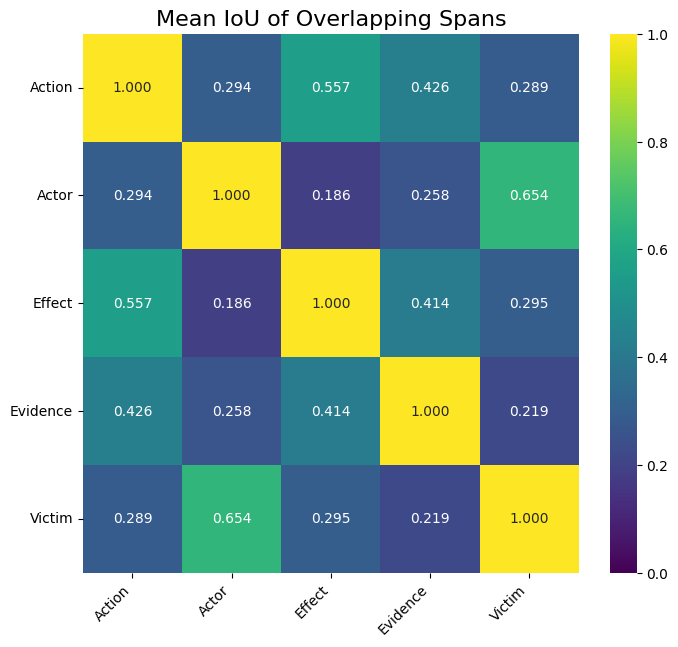


Top 3 Most Ambiguous (Overlapping) Marker Pairs:
- Actor <-> Victim: Mean IoU = 0.654 (based on 77 overlaps)
- Action <-> Effect: Mean IoU = 0.557 (based on 204 overlaps)
- Action <-> Evidence: Mean IoU = 0.426 (based on 187 overlaps)


In [10]:
# CELL 2: Mean IoU Matrix for Overlapping Spans
from collections import defaultdict
from typing import Tuple
import numpy as np

print("--- Calculating Mean IoU for Overlapping Spans ---")

# Helper function to calculate character-level IoU
def iou_char(a: Tuple[int,int], b: Tuple[int,int]) -> float:
    """Calculates Intersection over Union for two character spans."""
    inter_start = max(a[0], b[0])
    inter_end = min(a[1], b[1])
    inter = max(0, inter_end - inter_start)
    
    union = (a[1] - a[0]) + (b[1] - b[0]) - inter
    return inter / union if union > 0 else 0.0

# 1. Initialize data structures
# Use the constants loaded in the first cell or redefine them for clarity
ALLOWED_MARKERS = {"Actor", "Action", "Effect", "Victim", "Evidence"}
labels_sorted = sorted(list(ALLOWED_MARKERS))

sum_iou = defaultdict(float)
cnt_iou = defaultdict(int)

# 2. Iterate through all documents and their spans
for _, row in df_all.iterrows():
    # Filter for valid markers and sort by position for efficient pairing
    spans = sorted(
        [
            (m["label"], m["start"], m["end"]) 
            for m in (row["markers"] or []) 
            if m.get("label") in ALLOWED_MARKERS and isinstance(m.get("start"), int)
        ],
        key=lambda x: (x[1], x[2])
    )
    
    # Consider all unique pairs of spans within the document
    for i in range(len(spans)):
        li, si, ei = spans[i]
        for j in range(i + 1, len(spans)):
            lj, sj, ej = spans[j]
            
            # Efficient check for overlap: if the start of one is after the end of the other, they don't overlap.
            # The sorted list makes this even faster, as we can break early.
            if sj >= ei:
                break 

            # Calculate IoU for the overlapping pair
            iou = iou_char((si, ei), (sj, ej))
            if iou > 0:
                # Create a canonical key for the pair of labels (e.g., ('Action', 'Effect'))
                a, b = sorted([li, lj])
                key = (a, b)
                sum_iou[key] += iou
                cnt_iou[key] += 1

# 3. Construct the final matrix for plotting
mat = np.zeros((len(labels_sorted), len(labels_sorted)), dtype=float)

for i, a in enumerate(labels_sorted):
    for j, b in enumerate(labels_sorted):
        if i == j:
            mat[i, j] = 1.0  # A label has perfect IoU with itself
        else:
            key = tuple(sorted([a, b]))
            if cnt_iou[key] > 0:
                mat[i, j] = sum_iou[key] / cnt_iou[key]

# 4. Plot the heatmap
plt.figure(figsize=(8, 7))
sns.heatmap(
    mat, 
    annot=True, 
    fmt=".3f", 
    cmap="viridis", 
    xticklabels=labels_sorted, 
    yticklabels=labels_sorted,
    vmin=0,
    vmax=1
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Mean IoU of Overlapping Spans", fontsize=16)

# Save the plot
plot_path = PIPELINE_OUTPUT_DIR / "mean_iou_matrix.png"
plt.savefig(plot_path, bbox_inches='tight')
print(f"\nMean IoU heatmap saved to {plot_path}")

plt.show()

# --- Print the most ambiguous pairs for the report ---
print("\nTop 3 Most Ambiguous (Overlapping) Marker Pairs:")
top_pairs = sorted(cnt_iou.keys(), key=lambda k: mat[labels_sorted.index(k[0]), labels_sorted.index(k[1])], reverse=True)
for pair in top_pairs[:3]:
    mean_val = sum_iou[pair] / cnt_iou[pair]
    print(f"- {pair[0]} <-> {pair[1]}: Mean IoU = {mean_val:.3f} (based on {cnt_iou[pair]} overlaps)")

### Linguistic Feature Analysis

This cell implements the analysis of absolutist language, providing both a statistical summary and a clear visualization to show the correlation with the conspiracy label.

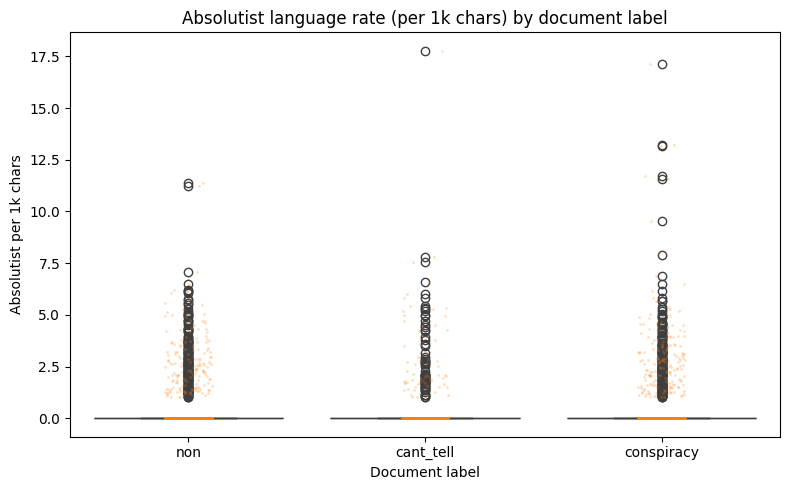

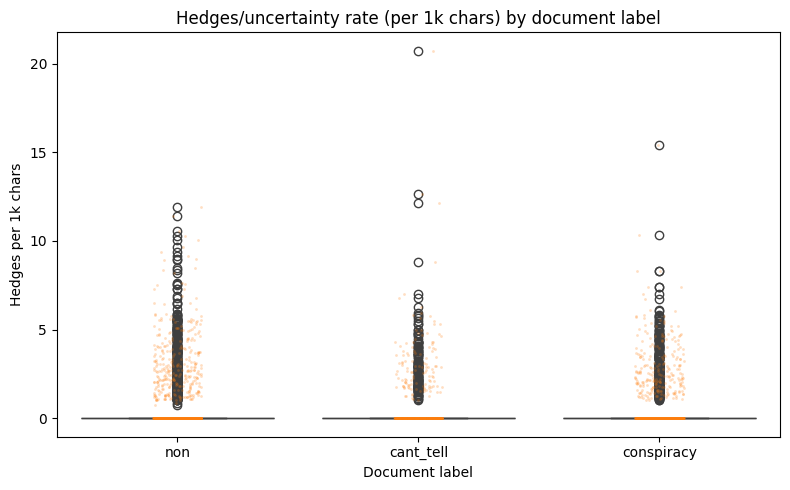

In [11]:
# --- Absolutist vs Hedge analysis  ---
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ABSOLUTIST = [
    "always","never","everyone","no one","impossible","undeniable","without a doubt",
    "completely","totally","entirely","absolutely","certainly","no doubt","no doubts",
]
HEDGES = [
    "maybe","perhaps","possibly","likely","unlikely","appears","seems","suggests","might","could","may","arguably",
]

def make_word_boundary_regex(terms):
    # (?i) case-insensitive; protect multi-word phrases; word boundaries on both sides
    return re.compile(r"(?i)(?<!\w)(" + "|".join(map(re.escape, terms)) + r")(?!\w)")

abs_pat = make_word_boundary_regex(ABSOLUTIST)
hed_pat = make_word_boundary_regex(HEDGES)

def count_pat(s, pat):
    if not isinstance(s, str):
        return 0
    return len(pat.findall(s))

df_all = pd.concat([train_df.assign(split="train"), dev_df.assign(split="dev")], ignore_index=True)
df_all["char_len"] = df_all["text"].str.len().fillna(0).clip(lower=1)

df_all["abs_cnt"] = df_all["text"].apply(lambda s: count_pat(s, abs_pat))
df_all["hed_cnt"] = df_all["text"].apply(lambda s: count_pat(s, hed_pat))

df_all["abs_per_1k"] = 1000.0 * df_all["abs_cnt"] / df_all["char_len"]
df_all["hed_per_1k"] = 1000.0 * df_all["hed_cnt"] / df_all["char_len"]

# Save summary stats (per class)
summary = (
    df_all.groupby("doc_label")[["abs_per_1k","hed_per_1k"]]
    .agg(["mean","median","std","count"])
    .round(4)
)
summary.to_csv(PIPELINE_OUTPUT_DIR / "absolutist_hedge_summary.csv")

# Plot: rates per class
plt.figure(figsize=(8,5))
sns.boxplot(data=df_all, x="doc_label", y="abs_per_1k")
sns.stripplot(data=df_all, x="doc_label", y="abs_per_1k", dodge=False, alpha=0.25, size=2)
plt.title("Absolutist language rate (per 1k chars) by document label")
plt.xlabel("Document label")
plt.ylabel("Absolutist per 1k chars")
plt.tight_layout()
plt.savefig(PIPELINE_OUTPUT_DIR / "absolutist_language_rate_by_doc_label.png", dpi=200)

plt.figure(figsize=(8,5))
sns.boxplot(data=df_all, x="doc_label", y="hed_per_1k")
sns.stripplot(data=df_all, x="doc_label", y="hed_per_1k", dodge=False, alpha=0.25, size=2)
plt.title("Hedges/uncertainty rate (per 1k chars) by document label")
plt.xlabel("Document label")
plt.ylabel("Hedges per 1k chars")
plt.tight_layout()
plt.savefig(PIPELINE_OUTPUT_DIR / "hedges_rate_by_doc_label.png", dpi=200)

# Optional: per-subreddit averages (n>=20) for domain effects
if "subreddit" in df_all.columns:
    sub_stats = (
        df_all.groupby(["subreddit","doc_label"])
        .agg(n=("doc_id","nunique"), abs_per_1k=("abs_per_1k","mean"), hed_per_1k=("hed_per_1k","mean"))
        .reset_index()
    )
    sub_stats[sub_stats["n"]>=20].to_csv(PIPELINE_OUTPUT_DIR / "absolutist_hedge_by_subreddit.csv", index=False)


In [12]:
from math import isnan
from statistics import median

def cliffs_delta(a, b):
    # a,b are lists
    import itertools
    gt = lt = 0
    for x,y in itertools.product(a,b):
        if x > y: gt += 1
        elif x < y: lt += 1
    n1, n2 = len(a), len(b)
    return (gt - lt) / (n1*n2) if n1 and n2 else 0.0

def bh_correct(pvals):
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, dtype=float)
    cummin = 1.0
    for i, idx in enumerate(order[::-1], start=1):
        rank = m - i + 1
        val = pvals[idx] * m / rank
        cummin = min(cummin, val)
        adj[idx] = cummin
    return adj

# Example for abs_per_1k across classes (drop cant_tell if you want binary)
groups = {lab: g["abs_per_1k"].dropna().tolist()
          for lab, g in df_all.groupby("doc_label")}

from scipy.stats import mannwhitneyu
labs = sorted(groups.keys())
tests, pvals = [], []
for i in range(len(labs)):
    for j in range(i+1, len(labs)):
        a, b = groups[labs[i]], groups[labs[j]]
        stat, p = mannwhitneyu(a, b, alternative="two-sided")
        delta = cliffs_delta(a, b)
        tests.append({"metric":"abs_per_1k", "a":labs[i], "b":labs[j], "p":p, "cliffs_delta":delta})
        pvals.append(p)

adj = bh_correct(np.array(pvals))
for k,v in zip(tests, adj):
    k["p_bh"] = float(v)

pd.DataFrame(tests).to_csv(PIPELINE_OUTPUT_DIR / "lexical_effect_sizes.csv", index=False)


### Cell 4: Export "Hard" Examples for Few-Shot Prompting

This cell identifies documents that are difficult based on three criteria: high Action/Effect ambiguity, high subreddit label entropy, and misclassification by a simple baseline model. It then saves these examples to a file.

In [5]:
# CELL 4: Export "Hard" Examples for Few-Shot Prompting
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from scipy.stats import entropy

print("\n--- Identifying and Exporting Hard Examples ---")

hard_examples = {}

# --- Criterion 1: High Action/Effect Overlap ---
def get_max_action_effect_iou(markers):
    if not isinstance(markers, list): return 0.0
    actions = [(m['start'], m['end']) for m in markers if m['label'] == 'Action' and m['start'] is not None]
    effects = [(m['start'], m['end']) for m in markers if m['label'] == 'Effect' and m['start'] is not None]
    if not actions or not effects: return 0.0
    
    max_iou = 0.0
    for s1, e1 in actions:
        for s2, e2 in effects:
            # Check for overlap
            if max(s1, s2) < min(e1, e2):
                inter = max(0, min(e1, e2) - max(s1, s2))
                union = (e1 - s1) + (e2 - s2) - inter
                iou = inter / union if union > 0 else 0.0
                if iou > max_iou: max_iou = iou
    return max_iou

df_all['max_ae_iou'] = df_all['markers'].apply(get_max_action_effect_iou)
high_iou_docs = df_all[df_all['max_ae_iou'] > 0.7]

for _, row in high_iou_docs.iterrows():
    doc_id = row['doc_id']
    if doc_id not in hard_examples: hard_examples[doc_id] = {'reasons': [], 'text': row['text']}
    hard_examples[doc_id]['reasons'].append(f"High Action/Effect IoU ({row['max_ae_iou']:.2f})")

print(f"Found {len(high_iou_docs)} docs with high Action/Effect overlap (IoU > 0.7).")

# --- Criterion 2: High Subreddit Label Entropy ---
sub_counts = df_all.groupby(['subreddit', 'doc_label']).size().unstack(fill_value=0)
sub_probs = sub_counts.div(sub_counts.sum(axis=1), axis=0)
sub_entropy = sub_probs.apply(lambda row: entropy(row, base=2), axis=1)

df_all['subreddit_entropy'] = df_all['subreddit'].map(sub_entropy)
high_entropy_docs = df_all[df_all['subreddit_entropy'] > 1.5] # Max entropy for 3 labels is ~1.58

for _, row in high_entropy_docs.iterrows():
    doc_id = row['doc_id']
    if doc_id not in hard_examples: hard_examples[doc_id] = {'reasons': [], 'text': row['text']}
    hard_examples[doc_id]['reasons'].append(f"High Subreddit Entropy ({row['subreddit_entropy']:.2f})")

print(f"Found {len(high_entropy_docs)} docs from ambiguous subreddits (Entropy > 1.5).")

# --- Criterion 3: Misclassified by a Simple Baseline (on Dev Set) ---
df_binary_train = train_df[train_df['doc_label'].isin(['conspiracy', 'non'])]
df_binary_dev = dev_df[dev_df['doc_label'].isin(['conspiracy', 'non'])]

if not df_binary_dev.empty:
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
    X_train = vectorizer.fit_transform(df_binary_train['text'])
    y_train = df_binary_train['doc_label']
    X_dev = vectorizer.transform(df_binary_dev['text'])
    
    model = LogisticRegression(random_state=42, class_weight='balanced')
    model.fit(X_train, y_train)
    
    probs = model.predict_proba(X_dev)
    preds = model.classes_[np.argmax(probs, axis=1)]
    
    misclassified_mask = (preds != df_binary_dev['doc_label'])
    hard_to_classify = df_binary_dev[misclassified_mask].copy()
    
    # Error confidence = probability model assigned to the (wrong) predicted class
    hard_to_classify['error_confidence'] = np.max(probs[misclassified_mask], axis=1)

    # We are interested in confident errors
    confident_errors = hard_to_classify[hard_to_classify['error_confidence'] > 0.8]

    for _, row in confident_errors.iterrows():
        doc_id = row['doc_id']
        if doc_id not in hard_examples: hard_examples[doc_id] = {'reasons': [], 'text': row['text']}
        hard_examples[doc_id]['reasons'].append(f"Baseline Confident Error (Conf: {row['error_confidence']:.2f})")
    
    print(f"Found {len(confident_errors)} docs confidently misclassified by baseline (Conf > 0.8).")

# --- Export the combined list ---
final_hard_list = [{'doc_id': k, **v} for k, v in hard_examples.items()]
output_path = PIPELINE_OUTPUT_DIR / "hard_examples.json"
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(final_hard_list, f, indent=2, ensure_ascii=False)

print(f"\nExported a total of {len(final_hard_list)} unique hard examples to {output_path}")
print("This file is now ready to be used for selecting high-quality few-shot examples for Bedrock.")


--- Identifying and Exporting Hard Examples ---
Found 74 docs with high Action/Effect overlap (IoU > 0.7).
Found 1124 docs from ambiguous subreddits (Entropy > 1.5).

Exported a total of 1167 unique hard examples to C:\Users\panagiotis\Desktop\GitHub\PsyChoMark_Semeval\data\derived\psycomark_official_split_20250928_232947\hard_examples.json
This file is now ready to be used for selecting high-quality few-shot examples for Bedrock.


### Analyze Span Position (Histogram Analysis)


--- Analyzing Normalized Span Position by Marker Type ---
Note: No labeled span data available for legend, so legend was omitted.

Span position analysis plot saved to C:\Users\panagiotis\Desktop\GitHub\PsyChoMark_Semeval\data\derived\psycomark_official_split_20250928_232947\span_position_analysis.png

Span position analysis plot saved to C:\Users\panagiotis\Desktop\GitHub\PsyChoMark_Semeval\data\derived\psycomark_official_split_20250928_232947\span_position_analysis.png


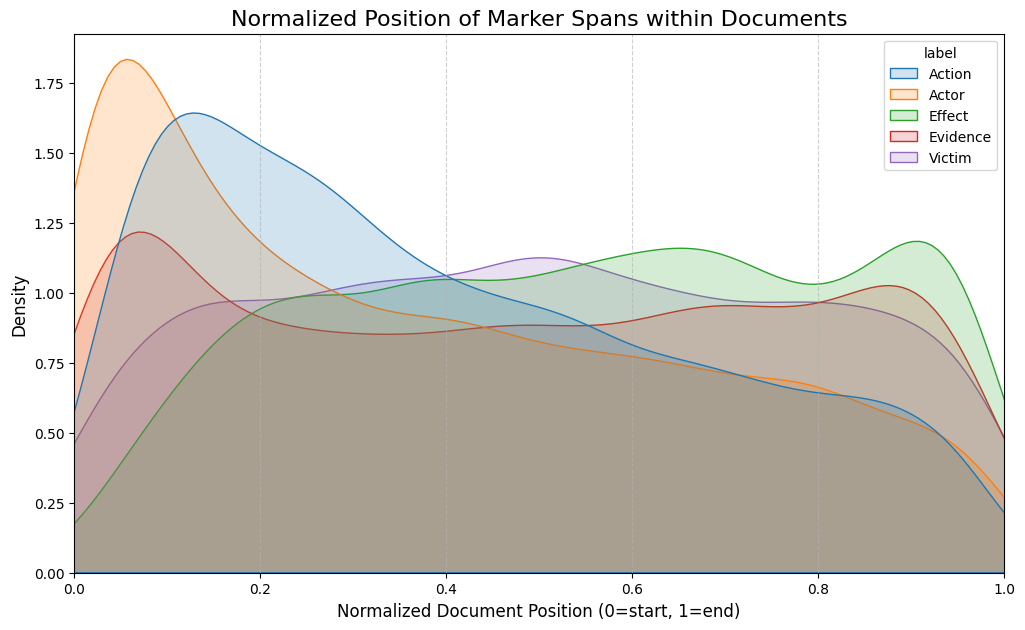


Interpretation: This plot shows the distribution of where each marker type tends to appear in a document.
For example, if the 'Evidence' curve is skewed to the right, it suggests that authors tend to present
their evidence towards the end of their statement. If 'Actor' is skewed left, it suggests the conspirators
are often introduced early. These patterns can reveal narrative structures.



In [11]:
# CELL 5: Analyze Span Position within Documents


print("\n--- Analyzing Normalized Span Position by Marker Type ---")


# Ensure the main dataframe has text length for normalization
df_all['text_len'] = df_all['text'].str.len()


# Align doc_id dtypes so the merge succeeds
df_spans = df_spans.copy()
df_spans['doc_id'] = df_spans['doc_id'].astype(df_all['doc_id'].dtype, copy=False)


# Join text length to our spans dataframe
df_spans_with_len = df_spans.merge(
    df_all[['doc_id', 'text_len']],
    on='doc_id',
    how='left',
    validate='many_to_one'
 )


missing_text_len = df_spans_with_len['text_len'].isna().sum()
if missing_text_len:
    print(f"Warning: {missing_text_len} spans lacked matching text length; dropping affected rows.")


# Drop any rows lacking required information
df_spans_with_len = df_spans_with_len.dropna(subset=['text_len', 'label']).copy()


if df_spans_with_len.empty:
    print("No span markers with valid text length available; skipping span position plot.")
else:
    # Calculate the normalized start position of each span's center
    # We use the center of the span: (start + end) / 2
    df_spans_with_len['norm_center_pos'] = (
        (df_spans_with_len['start'] + df_spans_with_len['end']) / 2
    ) / df_spans_with_len['text_len']


    # Create the plot
    plt.figure(figsize=(12, 7))
    ax = sns.kdeplot(
        data=df_spans_with_len,
        x='norm_center_pos',
        hue='label',
        hue_order=sorted(ALLOWED_MARKERS), # Use the constant from the first cell
        fill=True,
        common_norm=False, # Normalize each density plot independently
        alpha=0.2
    )


    plt.title('Normalized Position of Marker Spans within Documents', fontsize=16)
    plt.xlabel('Normalized Document Position (0=start, 1=end)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.xlim(0, 1)
    plt.grid(axis='x', linestyle='--', alpha=0.6)


    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(title='Marker Type')
    else:
        print("Note: No labeled span data available for legend, so legend was omitted.")


    # Save the plot
    plot_path = PIPELINE_OUTPUT_DIR / "span_position_analysis.png"
    plt.savefig(plot_path)
    print(f"\nSpan position analysis plot saved to {plot_path}")


    plt.show()


    # --- Interpretation ---
    print("""
Interpretation: This plot shows the distribution of where each marker type tends to appear in a document.
For example, if the 'Evidence' curve is skewed to the right, it suggests that authors tend to present
their evidence towards the end of their statement. If 'Actor' is skewed left, it suggests the conspirators
are often introduced early. These patterns can reveal narrative structures.
""")